In [1]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
%matplotlib inline

RANDOM_SEED = 79
rng = np.random.default_rng(RANDOM_SEED)

# UAAP Basketball Across Seasons

In the [first notebook](basketball%20outcomes%20using%20probabilistic%20programming.ipynb), we modeled a single season, UAAP Season 79 (2016), and used the first half of the season to predict the second. It worked well: the model picked 21 of 28 second-round winners and got the Final Four right.

Here we zoom out to every season with results on Wikipedia, from Season 66 (2003) to Season 88 (2025), and ask some bigger questions:
* **How much carries over from one season to the next?** Rosters change every year, but programs, coaches and recruiting don't.
* **How predictable is a season**, halfway through and before it starts?
* **What do champions look like?** Do they win with offense or defense? Is the best team usually the champion?

To answer them, we'll make two changes to the model:
1. **One joint model for all seasons.** Each team's offensive and defensive strength evolves from season to season, so a team's past informs its present.
2. **A pace effect.** Some games are fast and high-scoring, others slow, and that moves *both* teams' scores together. We'll see that the Poisson model from the first notebook can't capture this, and that it made the model underconfident.

# The Data

The script `scrape_uaap.py` collects every season's men's tournament results from Wikipedia: the score of every elimination-round game, which round it was in, each team's final place in the elimination round, and the champion. We'll load its output.

17 seasons have a results table on Wikipedia: Season 66 (2003), Seasons 71–72 (2008–2009), and every season from 74 (2011) to 88 (2025) except Season 83, which was cancelled because of COVID-19. Each season is a double round-robin: every team plays every other team twice, for 56 games (Season 66 is missing 2).

In [2]:
TEAMS = ["AdU", "ADMU", "DLSU", "FEU", "NU", "UE", "UP", "UST"]
team_idx = pd.Series(np.arange(len(TEAMS)), index=TEAMS)

games = pd.read_csv("uaap_men_games.csv")
seasons = pd.read_csv("uaap_men_seasons.csv")
SEASONS = sorted(games.season.unique())
games.head()

,season,year,home,away,home_score,away_score,round
0,66,2003,AdU,ADMU,62,70,1
1,66,2003,ADMU,AdU,69,55,2
2,66,2003,AdU,DLSU,61,81,1
3,66,2003,DLSU,AdU,82,74,2
4,66,2003,AdU,FEU,53,57,1


In [3]:
def summarize_season(d):
    return pd.Series({
        "year": d.year.iloc[0],
        "champion": d.team[d.champion].iloc[0],
        "champion_wins": d.wins[d.champion].iloc[0],
        "champion_place": d.place[d.champion].iloc[0],
        "final_four": ", ".join(d.sort_values("place").team[d.place <= 4]),
    })


season_summary = seasons.groupby("season").apply(summarize_season)
season_summary

,year,champion,champion_wins,champion_place,final_four
season,,,,,
66,2003,FEU,10,2,"UE, ADMU, FEU, DLSU"
71,2008,ADMU,13,1,"ADMU, DLSU, FEU, UE"
72,2009,ADMU,13,1,"ADMU, FEU, UE, UST"
74,2011,ADMU,13,1,"ADMU, AdU, FEU, UST"
75,2012,ADMU,12,1,"ADMU, UST, NU, DLSU"
76,2013,DLSU,10,2,"NU, DLSU, FEU, UST"
77,2014,NU,9,4,"ADMU, FEU, DLSU, NU"
78,2015,FEU,11,2,"UST, FEU, ADMU, NU"
79,2016,DLSU,13,1,"DLSU, ADMU, FEU, AdU"


Ateneo (ADMU) dominates this era with 8 of these 17 titles (and the 2010 title too, in a season missing from the data). Every champion finished in the top 4 of the elimination round, which is how you get into the playoffs, and most finished in the top 2.

## Why scores aren't Poisson

The first notebook modeled each team's points as a Poisson count. A Poisson distribution has its variance equal to its mean, so a team averaging 70 points should have a standard deviation of about $\sqrt{70} \approx 8.4$ points. Let's check that against all 950 games, and look at how the two teams' scores in a game relate to each other.

Average points per team per game: 71.1
Standard deviation of a team's points: 11.9 (Poisson: 8.4)
Correlation between the two teams' points in a game: 0.39


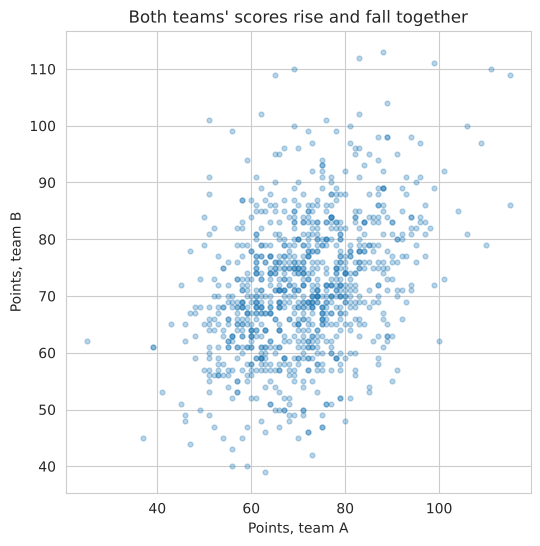

In [4]:
points = pd.concat([games.home_score, games.away_score])
print(f"Average points per team per game: {points.mean():.1f}")
print(f"Standard deviation of a team's points: {points.std():.1f} (Poisson: {np.sqrt(points.mean()):.1f})")
print(f"Correlation between the two teams' points in a game: {games.home_score.corr(games.away_score):.2f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(games.home_score, games.away_score, alpha=0.3, s=12)
ax.set_xlabel("Points, team A")
ax.set_ylabel("Points, team B")
ax.set_title("Both teams' scores rise and fall together")
plt.show()

Scores vary much more than a Poisson distribution allows, and the two teams' scores are positively correlated. Both have the same explanation: **pace**. In a fast game, both teams get more possessions and both score more; in a slow, defensive game, both score less.

What matters for winning, though, is the *margin*, and pace mostly cancels out of it. A Poisson model gets both wrong: it understates how much totals vary, and it *overstates* how much margins vary, which makes it too unsure about who will win. We'll fix both with a pace term shared by both teams in a game, plus a separate, smaller amount of noise for each team's score.

# The Joint Model

As before, each team $t$ in season $s$ has an offensive strength $offense_{s,t}$ and a defensive strength $defense_{s,t}$, and each season has a baseline scoring level $intercept_s$. For game $g$ in season $s$, between teams 1 and 2, the expected points of team 1 are

$$\theta_{g1} = exp(intercept_s + pace_g + offense_{s,1} - defense_{s,2})$$

and similarly for team 2. The new term, $pace_g$, is shared by both teams: a fast game scales up both teams' expected points by the same factor.

Instead of a Poisson count, each team's points are normally distributed around their expected value:

$$y_{gj} \sim Normal(\theta_{gj}, \sigma)$$

Because pace is shared, it cancels out of the margin, and $\sigma$ alone controls how unpredictable the margin is.

## Strengths that evolve across seasons

To link the seasons, a team's strength this season is a fraction $\rho$ of its strength last season, plus something new:

$$offense_{s,t} = \rho_{off} \cdot offense_{s-1,t} + \sqrt{1 - \rho_{off}^2} \cdot \sigma_{off} \cdot z_{s,t}$$

where $z_{s,t}$ is standard normal (and likewise for defense). This is an *autoregressive* process. If $\rho$ is close to 1, teams stay as good or as bad as they were; if it's close to 0, every season starts from scratch. The $\sqrt{1 - \rho^2}$ factor keeps the spread of team strengths, $\sigma_{off}$, the same in every season. When there's a gap of $k$ seasons in the data (Season 66 to 71, for example), the carry-over is $\rho^k$ instead of $\rho$.

As in the first notebook, offensive and defensive strengths sum to zero within each season.

## Priors

* $\rho_{off}, \rho_{def} \sim Beta(2, 2)$: anywhere between 0 and 1, centered on 0.5
* $\sigma_{off}, \sigma_{def} \sim HalfNormal(0.5)$
* $intercept_s \sim Normal(4, 1)$, separately for each season (each season has plenty of games to pin down its scoring level)
* $pace_g \sim Normal(0, \sigma_{pace})$, with $\sigma_{pace} \sim HalfNormal(0.5)$
* $\sigma \sim HalfNormal(20)$ points

We'll also keep the first notebook's Poisson model as an option, to compare the two.

In [5]:
def autoregressive(z, rho, sigma, gaps):
    """Strengths for consecutive seasons from standard normal innovations z (one row per season)."""
    rows = [sigma * z[0]]
    for k, gap in enumerate(gaps, start=1):
        carry_over = rho**gap
        rows.append(carry_over * rows[-1] + pt.sqrt(1 - carry_over**2) * sigma * z[k])
    return pt.stack(rows)


PRIORS = {
    "rho": (2, 2),           # Beta prior on the season-to-season carry-over
    "sigma_strength": 0.5,   # HalfNormal prior on the spread of offensive and defensive strengths
    "intercept": (4, 1),     # Normal prior on each season's scoring level (log points)
    "sigma_pace": 0.5,       # HalfNormal prior on the spread of game paces
    "sigma": 20,             # HalfNormal prior on the noise in each team's points
}


def build_model(df, likelihood="normal", priors=PRIORS):
    """Joint model for every season in df. likelihood is "normal" (with pace) or "poisson"."""
    model_seasons = np.sort(df.season.unique())
    season_idx = pd.Series(np.arange(len(model_seasons)), index=model_seasons)
    s = season_idx[df.season].values
    home = team_idx[df.home].values
    away = team_idx[df.away].values
    gaps = np.diff(model_seasons)

    coords = {"season": model_seasons, "team": TEAMS, "game": np.arange(len(df))}
    with pm.Model(coords=coords) as model:
        # how much of a team's strength carries over to the next season
        rho_att = pm.Beta("rho_att", *priors["rho"])
        rho_def = pm.Beta("rho_def", *priors["rho"])
        # spread of team strengths within a season
        sigma_att = pm.HalfNormal("sigma_att", priors["sigma_strength"])
        sigma_def = pm.HalfNormal("sigma_def", priors["sigma_strength"])
        z_att = pm.ZeroSumNormal("z_att", sigma=1, dims=("season", "team"))  # sums to zero over teams
        z_def = pm.ZeroSumNormal("z_def", sigma=1, dims=("season", "team"))
        atts = pm.Deterministic("atts", autoregressive(z_att, rho_att, sigma_att, gaps), dims=("season", "team"))
        defs = pm.Deterministic("defs", autoregressive(z_def, rho_def, sigma_def, gaps), dims=("season", "team"))

        # league scoring level, by season
        intercept = pm.Normal("intercept", *priors["intercept"], dims="season")

        log_home_theta = intercept[s] + atts[s, home] - defs[s, away]
        log_away_theta = intercept[s] + atts[s, away] - defs[s, home]

        if likelihood == "poisson":
            pm.Poisson("home_points", pt.exp(log_home_theta), observed=df.home_score.values, dims="game")
            pm.Poisson("away_points", pt.exp(log_away_theta), observed=df.away_score.values, dims="game")
        else:
            # pace of each game, shared by both teams
            sigma_pace = pm.HalfNormal("sigma_pace", priors["sigma_pace"])
            z_pace = pm.Normal("z_pace", 0, 1, dims="game")
            pace = pm.Deterministic("pace", sigma_pace * z_pace, dims="game")
            sigma = pm.HalfNormal("sigma", priors["sigma"])
            pm.Normal("home_points", pt.exp(log_home_theta + pace), sigma, observed=df.home_score.values, dims="game")
            pm.Normal("away_points", pt.exp(log_away_theta + pace), sigma, observed=df.away_score.values, dims="game")
    return model

## Prior predictive check

Before fitting, it's worth checking what the priors imply about the data. We'll simulate scores from the model using only the priors, and compare them with the real scores.

In [6]:
with build_model(games):
    prior = pm.sample_prior_predictive(draws=500, random_seed=RANDOM_SEED)

prior_home = prior.prior_predictive["home_points"].values.ravel()
prior_away = prior.prior_predictive["away_points"].values.ravel()
quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]
pd.DataFrame(
    {
        "points (prior)": np.quantile(np.concatenate([prior_home, prior_away]), quantiles),
        "points (data)": np.quantile(points, quantiles),
        "margin (prior)": np.quantile(np.abs(prior_home - prior_away), quantiles),
        "margin (data)": np.quantile(np.abs(games.home_score - games.away_score), quantiles),
    },
    index=pd.Index(quantiles, name="quantile"),
).round(0)

Sampling: [away_points, home_points, intercept, rho_att, rho_def, sigma, sigma_att, sigma_def, sigma_pace, z_att, z_def, z_pace]


,points (prior),points (data),margin (prior),margin (data)
quantile,,,,
0.05,-2.0,52.0,2.0,1.0
0.25,24.0,63.0,13.0,4.0
0.50,58.0,71.0,35.0,9.0
0.75,131.0,79.0,85.0,15.0
0.95,470.0,91.0,367.0,26.0


The priors are *weakly informative*: they allow every realistic score and margin, but also many unrealistic ones, such as negative scores or a team scoring 400 points. That's wider than it needs to be, but with 950 games the data easily overwhelm priors this vague. We'll confirm that with a sensitivity check after fitting.

# Fitting the Model to Every Season

The strengths and the pace effects are written in *non-centered* form (a scale times a standard normal), which makes the model much easier for NUTS to sample. With about 1,300 parameters, this takes a few minutes.

In [7]:
def check_fit(fitted):
    # divergences, and the worst r_hat and smallest effective sample size over every parameter
    rhat, ess = az.rhat(fitted).to_dataset(), az.ess(fitted).to_dataset()
    print(f"Divergent transitions: {int(fitted.sample_stats.diverging.sum())}, "
          f"largest r_hat: {max(float(rhat[v].max()) for v in rhat.data_vars):.3f}, "
          f"smallest effective sample size: {min(float(ess[v].min()) for v in ess.data_vars):.0f}")


with build_model(games):
    idata = pm.sample(draws=1000, tune=1000, chains=4, random_seed=RANDOM_SEED, progressbar=False)

check_fit(idata)
hyperparameters = ["rho_att", "rho_def", "sigma_att", "sigma_def", "sigma_pace", "sigma"]
az.summary(idata, var_names=hyperparameters)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [rho_att, rho_def, sigma_att, sigma_def, z_att, z_def, intercept, sigma_pace, z_pace, sigma]


.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.


Divergent transitions: 0, largest r_hat: 1.006, smallest effective sample size: 1243


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
rho_att,0.63,0.088,0.49,0.76,1299,1742,1.00,0.0024,0.0018
rho_def,0.732,0.071,0.61,0.83,1444,1915,1.00,0.0019,0.0012
sigma_att,0.066,0.0072,0.056,0.078,1620,2182,1.00,0.00018,0.00017
sigma_def,0.0671,0.0079,0.056,0.081,1819,2342,1.00,0.00019,0.00013
sigma_pace,0.0949,0.0037,0.089,0.1,1242,2038,1.00,0.0001,5.2e-05
sigma,6.724,0.162,6.5,7,1543,2260,1.00,0.0041,0.0022


# Checking the Model

The sampler converged, but that only means we computed the posterior correctly, not that the model is any good. Three more checks:
1. **Posterior predictive check**: do seasons simulated from the fitted model look like the real ones?
2. **Fake-data check**: if we simulate data from known parameter values, does the model recover them?
3. **Prior sensitivity**: do the conclusions change with different priors?

## Posterior predictive check

We'll simulate the 950 games again from the fitted model, many times, and compare summaries of the simulated data with the real data. Each replication draws new paces and new noise, as if the games were played again. To show what the pace effect buys us, we'll do the same for the same joint model with the Poisson likelihood from the first notebook.

In [8]:
with build_model(games, likelihood="poisson"):
    idata_poisson = pm.sample(draws=1000, tune=1000, chains=4, random_seed=RANDOM_SEED, progressbar=False)
check_fit(idata_poisson)


def replicate(idata, df, n_reps=300, rng=rng):
    # Replicated home and away points for the games in df, one row per replication
    post = idata.posterior.to_dataset().stack(sample=("chain", "draw"))
    pick = rng.integers(post.sizes["sample"], size=n_reps)
    season_idx = pd.Series(np.arange(post.sizes["season"]), index=post.season.values)
    s, home, away = season_idx[df.season].values, team_idx[df.home].values, team_idx[df.away].values
    intercept = post["intercept"].transpose("sample", ...).values[pick]
    atts = post["atts"].transpose("sample", ...).values[pick]
    defs = post["defs"].transpose("sample", ...).values[pick]
    log_home = intercept[:, s] + atts[:, s, home] - defs[:, s, away]
    log_away = intercept[:, s] + atts[:, s, away] - defs[:, s, home]
    if "sigma" not in post:
        return rng.poisson(np.exp(log_home)), rng.poisson(np.exp(log_away))
    pace = post["sigma_pace"].values[pick, None] * rng.normal(size=log_home.shape)
    noise = post["sigma"].values[pick, None]
    return (np.exp(log_home + pace) + noise * rng.normal(size=log_home.shape),
            np.exp(log_away + pace) + noise * rng.normal(size=log_home.shape))


def summary_stats(home, away):
    # Summaries of a set of games; home and away can have a leading replication axis
    home, away = np.atleast_2d(home), np.atleast_2d(away)
    margin, total = home - away, home + away
    centered = lambda x: x - x.mean(axis=-1, keepdims=True)
    corr = (centered(home) * centered(away)).mean(-1) / (home.std(-1) * away.std(-1))
    # spread of the teams' win totals within each season
    home_won = (margin > 0).astype(float)
    win_sd = []
    for season in SEASONS:
        in_season = (games.season == season).values
        h, a = team_idx[games.home[in_season]].values, team_idx[games.away[in_season]].values
        wins = home_won[:, in_season] @ np.eye(len(TEAMS))[h] + (1 - home_won[:, in_season]) @ np.eye(len(TEAMS))[a]
        win_sd.append(wins.std(axis=1))
    return pd.DataFrame({
        "SD of a team's points": np.concatenate([home, away], axis=1).std(axis=1),
        "Correlation of the two scores": corr,
        "SD of the total": total.std(axis=1),
        "SD of the margin": margin.std(axis=1),
        "Share of games within 5 points": (np.abs(margin) <= 5).mean(axis=1),
        "SD of win totals in a season": np.mean(win_sd, axis=0),
    })


observed = summary_stats(games.home_score.values, games.away_score.values).iloc[0]
ppc = pd.DataFrame({"data": observed})
for name, fitted in [("pace model", idata), ("Poisson model", idata_poisson)]:
    reps = summary_stats(*replicate(fitted, games))
    low, high = reps.quantile(0.05), reps.quantile(0.95)
    ppc[f"{name} (90% range)"] = [f"{l:.2f} – {h:.2f}" for l, h in zip(low, high)]
ppc.round(2)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [rho_att, rho_def, sigma_att, sigma_def, z_att, z_def, intercept]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.


Divergent transitions: 0, largest r_hat: 1.004, smallest effective sample size: 837


,data,pace model (90% range),Poisson model (90% range)
SD of a team's points,11.89,11.49 – 12.49,10.92 – 11.54
Correlation of the two scores,0.39,0.32 – 0.45,0.04 – 0.16
SD of the total,19.80,18.83 – 21.11,15.96 – 17.33
SD of the margin,13.15,12.59 – 13.78,14.39 – 15.75
Share of games within 5 points,0.32,0.27 – 0.32,0.26 – 0.31
SD of win totals in a season,3.43,3.10 – 3.46,2.80 – 3.23


The real data should fall inside the model's 90% range for each summary. For the pace model, they do: it reproduces the spread of scores, totals and margins, the correlation between the two teams' scores, and how spread out the win totals are (the share of close games is right at the edge). The Poisson model misses all six. Its simulated games have almost uncorrelated scores, totals that vary too little, margins that vary too much, too few close games, and win totals that are too bunched together. Those last three are the same problem: the Poisson model thinks games are more random than they are.

## Fake-data check

Here we make up a "true" set of parameters (we'll use the posterior medians), simulate 950 games on the real schedule from them, fit the model to the fake data, and see whether it finds the truth. This is the best way to check that the model, and especially the season-to-season carry-over $\rho$ with its gaps between seasons, can actually be learned from data like ours.

In [9]:
true_values = {v: float(idata.posterior[v].median()) for v in ["rho_att", "rho_def", "sigma_att", "sigma_def", "sigma_pace", "sigma"]}
with pm.do(build_model(games), true_values):
    fake = pm.sample_prior_predictive(draws=1, random_seed=RANDOM_SEED + 1)
fake_games = games.assign(
    home_score=fake.prior_predictive["home_points"].values.ravel(),
    away_score=fake.prior_predictive["away_points"].values.ravel(),
)
with build_model(fake_games):
    idata_fake = pm.sample(draws=1000, tune=1000, chains=4, random_seed=RANDOM_SEED, progressbar=False)
check_fit(idata_fake)
hyper_rhat = az.rhat(idata_fake, var_names=list(true_values)).to_dataset()
print(f"Largest r_hat among the hyperparameters: {max(float(hyper_rhat[v].max()) for v in hyper_rhat.data_vars):.3f}")
pace_rhat = az.rhat(idata_fake, var_names=["pace"]).to_dataset()["pace"]
print(f"Game paces with r_hat above 1.01: {int((pace_rhat > 1.01).sum())} of {pace_rhat.size}")

# One simulated dataset has its own "realized" values, which differ from the true ones by chance:
# the carry-over between consecutive seasons, and the spread of the strengths, paces and noise it actually drew.
fake_atts = fake.prior["atts"].values.reshape(len(SEASONS), len(TEAMS))
fake_defs = fake.prior["defs"].values.reshape(len(SEASONS), len(TEAMS))
fake_pace = fake.prior["pace"].values.ravel()
consecutive = np.diff(SEASONS) == 1


def realized_carry_over(x):
    previous, current = x[:-1][consecutive], x[1:][consecutive]
    return (previous * current).sum() / (previous**2).sum()


s_idx = pd.Series(np.arange(len(SEASONS)), index=SEASONS)[games.season].values
h_idx, a_idx = team_idx[games.home].values, team_idx[games.away].values
fake_intercept = fake.prior["intercept"].values.ravel()
fake_theta = np.exp(fake_intercept[s_idx] + fake_pace + fake_atts[s_idx, h_idx] - fake_defs[s_idx, a_idx])
zero_sum_scale = np.sqrt(len(TEAMS) / (len(TEAMS) - 1))  # strengths that sum to zero are slightly less spread out
realized = {
    "rho_att": realized_carry_over(fake_atts),
    "rho_def": realized_carry_over(fake_defs),
    "sigma_att": fake_atts.std() * zero_sum_scale,
    "sigma_def": fake_defs.std() * zero_sum_scale,
    "sigma_pace": fake_pace.std(),
    "sigma": (fake_games.home_score - fake_theta).std(),
}

recovery = pd.DataFrame(
    {
        "true": true_values,
        "realized": realized,
        "estimate": {v: float(idata_fake.posterior[v].median()) for v in true_values},
        "5%": {v: float(idata_fake.posterior[v].quantile(0.05)) for v in true_values},
        "95%": {v: float(idata_fake.posterior[v].quantile(0.95)) for v in true_values},
    }
)
recovery["true inside 90%"] = recovery["true"].between(recovery["5%"], recovery["95%"])
recovery["realized inside 90%"] = recovery["realized"].between(recovery["5%"], recovery["95%"])
recovery.round(3)

Sampling: [away_points, home_points, intercept, z_att, z_def, z_pace]


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [rho_att, rho_def, sigma_att, sigma_def, z_att, z_def, intercept, sigma_pace, z_pace, sigma]


.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 35 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Divergent transitions: 0, largest r_hat: 1.017, smallest effective sample size: 404
Largest r_hat among the hyperparameters: 1.005


Game paces with r_hat above 1.01: 2 of 950


,true,realized,estimate,5%,95%,true inside 90%,realized inside 90%
rho_att,0.633,0.484,0.380,0.181,0.559,False,True
rho_def,0.738,0.718,0.754,0.611,0.855,True,True
sigma_att,0.065,0.057,0.062,0.053,0.072,True,True
sigma_def,0.066,0.057,0.058,0.048,0.072,True,True
sigma_pace,0.095,0.091,0.086,0.080,0.091,False,True
sigma,6.716,6.615,6.726,6.486,6.980,True,True


In [10]:
# the true team strengths in every season, and how well the fit recovered them
for var in ["atts", "defs"]:
    true = fake.prior[var].values.reshape(len(SEASONS), len(TEAMS))
    post = idata_fake.posterior[var]
    low, high = post.quantile(0.05, ("chain", "draw")).values, post.quantile(0.95, ("chain", "draw")).values
    inside = ((true >= low) & (true <= high)).mean()
    corr = np.corrcoef(true.ravel(), post.median(("chain", "draw")).values.ravel())[0, 1]
    print(f"{var}: correlation between true and estimated strengths {corr:.2f}, true value inside the 90% interval {inside:.0%} of the time")

atts: correlation between true and estimated strengths 0.88, true value inside the 90% interval 90% of the time
defs: correlation between true and estimated strengths 0.85, true value inside the 90% interval 82% of the time


The fit converged reasonably well, though not perfectly: there are no divergences, but the largest $\hat{R}$ among the hyperparameters is 1.013, just above the usual 1.01 threshold, and 7 of the 950 game paces are above it too. The estimates are therefore slightly less precise than their intervals suggest, but that sampling error is far smaller than the gaps discussed below. The model recovers most parameters. Two estimates miss the *true* values, the offensive carry-over $\rho_{off}$ and the pace spread $\sigma_{pace}$, but this particular simulated dataset happened to draw a lower carry-over and pace spread than the true values (the `realized` column), and the estimates are consistent with what the data actually contain. It's also a reminder that with 17 seasons, $\rho$ is only known roughly: its 90% interval spans about 0.2 to 0.6 here.

The estimated team strengths track the true ones closely. The 90% intervals contain the true offensive strengths 90% of the time, as they should, and the true defensive strengths a bit less often (81%), so the defense intervals may be slightly too narrow.

## Prior sensitivity

Finally, let's refit with quite different priors: a uniform prior on $\rho$, and priors on the other parameters 2–5 times narrower. If the conclusions hold, the data are doing the work.

In [11]:
alternative_priors = {"rho": (1, 1), "sigma_strength": 0.2, "intercept": (4.25, 0.25), "sigma_pace": 0.2, "sigma": 10}
with build_model(games, priors=alternative_priors):
    idata_alt = pm.sample(draws=1000, tune=1000, chains=4, random_seed=RANDOM_SEED, progressbar=False)
check_fit(idata_alt)


def interval(fitted, var):
    q = fitted.posterior[var].quantile([0.05, 0.5, 0.95]).values
    return f"{q[1]:.3f} ({q[0]:.3f} – {q[2]:.3f})"


pd.DataFrame(
    {
        "default priors": {v: interval(idata, v) for v in true_values},
        "alternative priors": {v: interval(idata_alt, v) for v in true_values},
    }
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [rho_att, rho_def, sigma_att, sigma_def, z_att, z_def, intercept, sigma_pace, z_pace, sigma]


.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.


Divergent transitions: 0, largest r_hat: 1.005, smallest effective sample size: 1211


,default priors,alternative priors
rho_att,0.633 (0.481 – 0.765),0.637 (0.488 – 0.777)
rho_def,0.738 (0.606 – 0.838),0.755 (0.624 – 0.859)
sigma_att,0.065 (0.055 – 0.079),0.066 (0.055 – 0.078)
sigma_def,0.066 (0.055 – 0.081),0.067 (0.056 – 0.085)
sigma_pace,0.095 (0.089 – 0.101),0.095 (0.089 – 0.101)
sigma,6.716 (6.466 – 6.990),6.724 (6.468 – 6.993)


In [12]:
net_alt = (idata_alt.posterior["atts"] + idata_alt.posterior["defs"]).median(("chain", "draw")).values.ravel()
net_default = (idata.posterior["atts"] + idata.posterior["defs"]).median(("chain", "draw")).values.ravel()
print(f"Correlation of team strengths between the two fits: {np.corrcoef(net_default, net_alt)[0, 1]:.3f}")

Correlation of team strengths between the two fits: 1.000


The estimates barely move, so the priors aren't driving the conclusions.

# What Carries Over Between Seasons

$\rho$ is the share of a team's strength (relative to the league) that carries over to the next season. A convenient way to read it is as a *half-life*: the number of seasons until half of a team's edge is gone, $log(0.5) / log(\rho)$.

In [13]:
posterior = idata.posterior.to_dataset()
for kind, var in [("Offense", "rho_att"), ("Defense", "rho_def")]:
    rho = posterior[var].values.ravel()
    low, high = np.quantile(rho, [0.05, 0.95])
    half_life = np.log(0.5) / np.log(np.median(rho))
    print(f"{kind}: rho = {np.median(rho):.2f} (90% interval {low:.2f}–{high:.2f}), half-life {half_life:.1f} seasons")

Offense: rho = 0.63 (90% interval 0.48–0.77), half-life 1.5 seasons
Defense: rho = 0.74 (90% interval 0.61–0.84), half-life 2.3 seasons


A good part of a team's strength carries over, even though rosters change every year. Defense seems to carry over a bit more than offense, but the intervals overlap, so that's not certain.

## Team strengths over time

Let's look at each team's overall strength, offense plus defense, in every season. A strength of 0.1 means the team outscores an average team by about 10% of the points in a game, around 7 points.

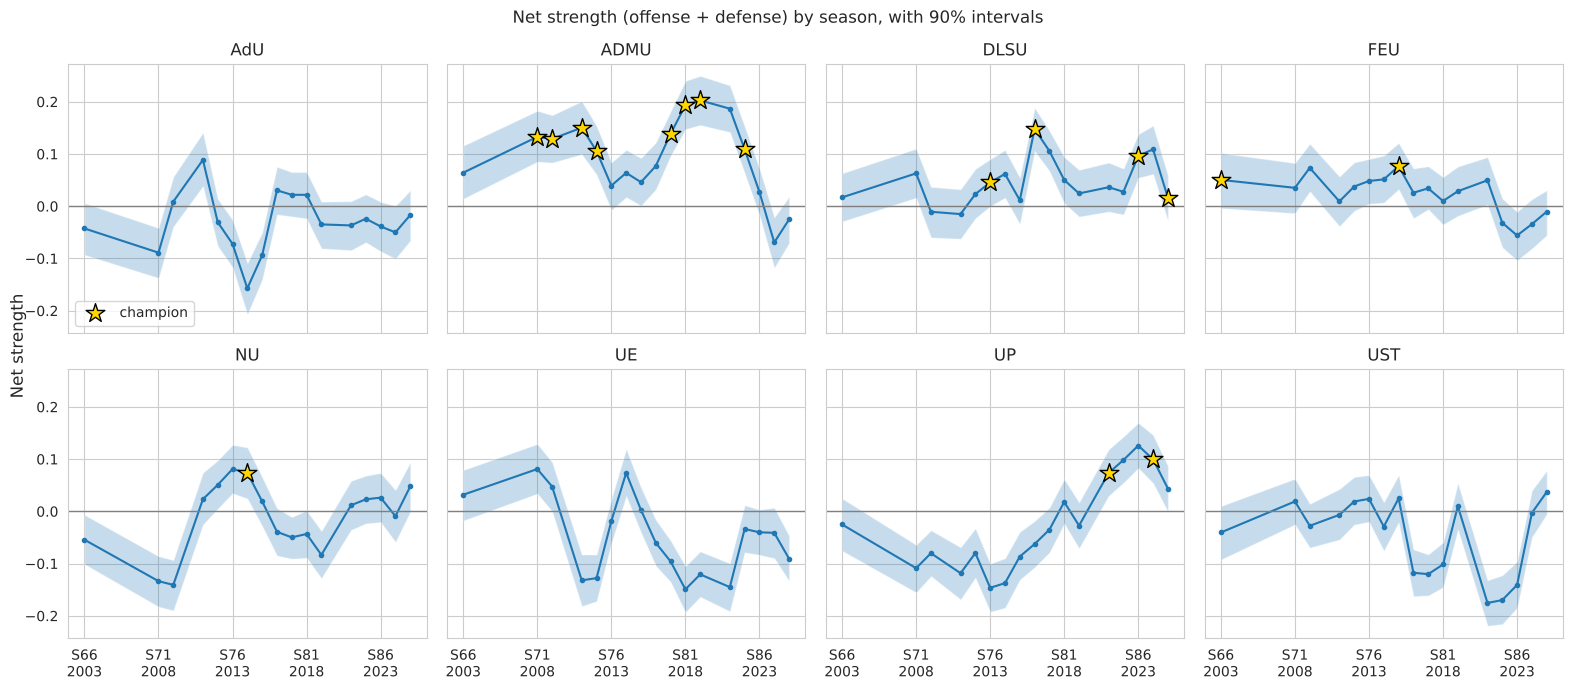

In [14]:
net = posterior["atts"] + posterior["defs"]
net_median = net.median(("chain", "draw")).to_pandas()
net_low = net.quantile(0.05, ("chain", "draw")).to_pandas()
net_high = net.quantile(0.95, ("chain", "draw")).to_pandas()
years = seasons.groupby("season").year.first()
TICKS = [66, 71, 76, 81, 86]  # seasons to label on the x axes


def label_seasons(ax):
    ax.set_xticks(TICKS, [f"S{s}\n{years.get(s, s + 1937)}" for s in TICKS])

champions = seasons[seasons.champion].set_index("season").team
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
for ax, team in zip(axes.ravel(), TEAMS):
    ax.fill_between(SEASONS, net_low[team], net_high[team], alpha=0.25)
    ax.plot(SEASONS, net_median[team], marker="o", markersize=3)
    won = champions[champions == team].index
    ax.scatter(won, net_median.loc[won, team], marker="*", s=200, color="gold", edgecolor="black", zorder=3,
               label="champion")
    ax.axhline(0, color="grey", lw=1)
    ax.set_title(team)
    label_seasons(ax)
axes[0, 0].legend(loc="lower left")
fig.suptitle("Net strength (offense + defense) by season, with 90% intervals")
fig.supylabel("Net strength")
plt.tight_layout()
plt.show()

Some patterns stand out:
* Ateneo's two dynasties, around 2008–2012 and 2017–2019, are clearly visible, and they were the strongest team in most of those seasons.
* Programs rise and fall over several seasons rather than jumping around, which is what $\rho$ measures. UP's climb from the bottom of the league in the early 2010s to two titles in the 2020s is a good example.
* Champions (the stars) are almost always among the strongest teams of their season, but not always *the* strongest.

## League scoring and parity

The intercept gives the scoring level of each season, and the spread of team strengths shows how lopsided each season was.

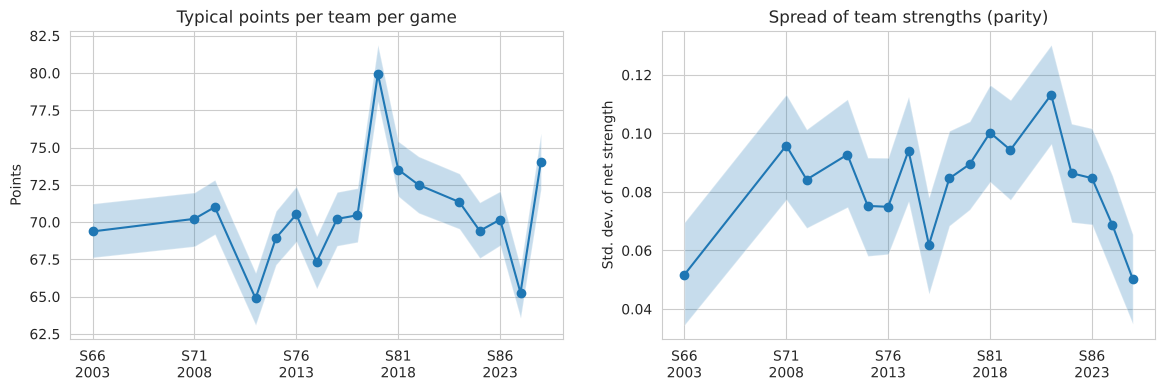

In [15]:
league_points = np.exp(posterior["intercept"])
spread = net.std("team")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, values, title, ylabel in [
    (axes[0], league_points, "Typical points per team per game", "Points"),
    (axes[1], spread, "Spread of team strengths (parity)", "Std. dev. of net strength"),
]:
    ax.fill_between(SEASONS, values.quantile(0.05, ("chain", "draw")).values,
                    values.quantile(0.95, ("chain", "draw")).values, alpha=0.25)
    ax.plot(SEASONS, values.median(("chain", "draw")).values, marker="o")
    label_seasons(ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
plt.show()

Scoring has stayed in a narrow band of about 65 to 75 points, with Season 80 (2017) as the high-scoring exception at about 80. Parity has varied more: the spread of team strengths grew from the late 2000s to a peak in Season 84 (2022), when Ateneo and UP were far ahead of everyone else, and the two most recent seasons have been the most balanced in the data.

## Pace and luck

How much does luck decide a game? The model separates the pace of a game, which moves both scores together, from the noise in each team's score, which moves the margin.

In [16]:
sigma_pace = posterior["sigma_pace"].median().item()
sigma = posterior["sigma"].median().item()
margin_sd = np.sqrt(2) * sigma
print(f"A typical game's pace moves both teams' scores by about ±{sigma_pace:.0%}, or ±{sigma_pace * 70:.0f} points at 70 points")
print(f"Game-to-game noise in the margin: about ±{margin_sd:.1f} points")
print(f"Poisson model's implied noise in the margin: about ±{np.sqrt(2 * 70):.1f} points")

expected_margin = np.arange(0, 21)
win_prob = norm.cdf(expected_margin / margin_sd)
pd.DataFrame({"expected_margin": expected_margin, "p_win": win_prob.round(2)}).set_index("expected_margin").loc[[0, 2, 4, 6, 8, 10, 15, 20]].T

A typical game's pace moves both teams' scores by about ±10%, or ±7 points at 70 points
Game-to-game noise in the margin: about ±9.5 points
Poisson model's implied noise in the margin: about ±11.8 points


expected_margin,0,2,4,6,8,10,15,20
p_win,0.5,0.58,0.66,0.74,0.8,0.85,0.94,0.98


So a team expected to win by 5 points wins about 70% of the time, and a 10-point favorite about 85% of the time. The Poisson model would have said less, because it assumes margins are noisier than they are.

## What champions look like

For each season, let's rank the champion's offense, defense and net strength among the 8 teams.

In [17]:
def rank_in_season(values):
    """Rank of each team within each season (1 = best), from posterior medians."""
    return values.median(("chain", "draw")).to_pandas().rank(axis=1, ascending=False).astype(int)


att_rank = rank_in_season(posterior["atts"])
def_rank = rank_in_season(posterior["defs"])
net_rank = rank_in_season(net)
champion_profile = pd.DataFrame(
    {
        "year": years[SEASONS],
        "champion": champions[SEASONS],
        "elimination_place": season_summary.champion_place,
        "offense_rank": [att_rank.loc[s, champions[s]] for s in SEASONS],
        "defense_rank": [def_rank.loc[s, champions[s]] for s in SEASONS],
        "net_rank": [net_rank.loc[s, champions[s]] for s in SEASONS],
    },
    index=pd.Index(SEASONS, name="season"),
)
champion_profile

,year,champion,elimination_place,offense_rank,defense_rank,net_rank
season,,,,,,
66,2003,FEU,2,7,1,2
71,2008,ADMU,1,3,1,1
72,2009,ADMU,1,3,1,1
74,2011,ADMU,1,1,1,1
75,2012,ADMU,1,1,1,1
76,2013,DLSU,2,3,3,3
77,2014,NU,4,5,1,2
78,2015,FEU,2,2,2,1
79,2016,DLSU,1,1,5,1


In [18]:
n = len(champion_profile)
print(f"Champions with the best net strength: {(champion_profile.net_rank == 1).sum()} of {n}, top 2: {(champion_profile.net_rank <= 2).sum()}")
print(f"Champions with a top-2 offense: {(champion_profile.offense_rank <= 2).sum()}, top-2 defense: {(champion_profile.defense_rank <= 2).sum()}")
print(f"Champions that finished 1st or 2nd in the elimination round (twice-to-beat): {(champion_profile.elimination_place <= 2).sum()} of {n}")

Champions with the best net strength: 10 of 17, top 2: 15
Champions with a top-2 offense: 12, top-2 defense: 11
Champions that finished 1st or 2nd in the elimination round (twice-to-beat): 15 of 17


The champion was usually the strongest team, or close to it, and the twice-to-beat advantage for the top 2 seeds is a big deal: 15 of 17 champions had it. Champions have won both ways, but the style has shifted. Through 2019, 10 of 12 champions had one of the two best defenses. Since 2022, all 5 champions had a top-2 offense, but only 1 had a top-2 defense; three of them had the 6th-best defense in the league. Five seasons is a small sample, so this is a pattern worth watching rather than a conclusion.

# How Predictable Are Seasons?

Now the real test: predicting games before they're played. For every season, we'll pretend we're at the halfway point, fit a model on what's known, and predict the second round, the Final Four and the champion. We'll compare three models:
* **Poisson, one season**: the first notebook's model, fit on the first round only.
* **Pace, one season**: the new likelihood with the pace effect, also fit on the first round only.
* **Pace, joint**: the full joint model, fit on all previous seasons plus the first round.

Comparing the first two shows the effect of the pace effect; comparing the last two shows the value of history. The joint model can also predict a season *before it starts*, from previous seasons alone, so we'll try that too.

To predict, we simulate the games the same way as in the first notebook: each simulation takes one posterior draw for every parameter. For a season the model hasn't seen yet, we first project each team's strengths forward one season using $\rho$. The playoffs follow the UAAP format: the top 2 seeds have a twice-to-beat advantage in the semifinals, the finals are best-of-three, and a team that sweeps the elimination round goes straight to the finals while the others play a stepladder. Ties in the standings are broken at random.

In [19]:
def posterior_draws(idata):
    """Posterior samples as numpy arrays with the sample dimension first."""
    post = idata.posterior.to_dataset().stack(sample=("chain", "draw"))
    names = [v for v in post.data_vars if not v.startswith("z_") and v != "pace"]
    return {v: post[v].transpose("sample", ...).values for v in names}, list(post.season.values)


def season_parameters(draws, fitted_seasons, season, n_sims, rng=rng):
    """One set of parameters for `season` per simulation, projected forward if the season wasn't fitted."""
    pick = rng.integers(len(draws["intercept"]), size=n_sims)
    p = {k: v[pick] for k, v in draws.items() if v.ndim == 1}
    if season in fitted_seasons:
        k = fitted_seasons.index(season)
        p["intercept"] = draws["intercept"][pick, k]
        p["atts"], p["defs"] = draws["atts"][pick, k], draws["defs"][pick, k]
        return p
    gap = season - fitted_seasons[-1]
    # a new season's scoring level varies like the past seasons' did
    past_intercepts = draws["intercept"][pick]
    p["intercept"] = past_intercepts.mean(axis=1) + past_intercepts.std(axis=1) * rng.normal(size=n_sims)
    for strength, rho, scale in [("atts", "rho_att", "sigma_att"), ("defs", "rho_def", "sigma_def")]:
        carry_over = (p[rho] ** gap)[:, None]
        z = rng.normal(size=(n_sims, len(TEAMS)))
        z -= z.mean(axis=1, keepdims=True)  # keep the sum-to-zero constraint
        p[strength] = carry_over * draws[strength][pick, -1] + np.sqrt(1 - carry_over**2) * p[scale][:, None] * z
    return p


def simulate_games(p, home, away, rng=rng):
    """Simulated points for games between team indices home and away, one row per simulation."""
    n_sims = len(p["intercept"])
    rows = np.arange(n_sims)[:, None]
    shape = np.broadcast_shapes((n_sims, 1), np.shape(home))
    log_home = p["intercept"][:, None] + p["atts"][rows, home] - p["defs"][rows, away]
    log_away = p["intercept"][:, None] + p["atts"][rows, away] - p["defs"][rows, home]
    if "sigma" not in p:  # Poisson model
        home_points, away_points = rng.poisson(np.exp(log_home)), rng.poisson(np.exp(log_away))
        tied = home_points == away_points
        while tied.any():  # overtime
            home_points[tied] += rng.poisson(np.exp(log_home[tied]) / 8)
            away_points[tied] += rng.poisson(np.exp(log_away[tied]) / 8)
            tied = home_points == away_points
        return home_points, away_points
    pace = p["sigma_pace"][:, None] * rng.normal(size=shape)
    noise = p["sigma"][:, None]
    home_points = np.exp(log_home + pace) + noise * rng.normal(size=shape)
    away_points = np.exp(log_away + pace) + noise * rng.normal(size=shape)
    return home_points, away_points


def bayes_winner(p, rng=rng):
    """A game simulator from posterior parameters: True where the first team outscores the second."""
    def home_wins(home, away):
        home_points, away_points = simulate_games(p, home, away, rng)
        return home_points > away_points
    return home_wins


def play_series(home_wins, high, low, high_needs, low_needs):
    """Winner of a playoff series: `high` needs high_needs wins, `low` needs low_needs wins."""
    n_games = high_needs + low_needs - 1  # playing this many games always decides the series
    high_won = home_wins(np.repeat(high[:, None], n_games, axis=1), np.repeat(low[:, None], n_games, axis=1))
    return np.where(high_won.sum(axis=1) >= high_needs, high, low)


def simulate_season(home_wins, played, upcoming, n_sims, rng=rng):
    """Simulate the rest of a season n_sims times with a game simulator home_wins(home, away).

    Returns P(home win) for each upcoming game, and each team's P(Final Four), P(champion) and expected wins.
    """
    winners = np.where(played.home_score > played.away_score, team_idx[played.home], team_idx[played.away])
    wins = np.tile(np.bincount(winners.astype(int), minlength=len(TEAMS)), (n_sims, 1))

    home, away = team_idx[upcoming.home].values, team_idx[upcoming.away].values
    home_won = home_wins(home, away)  # (n_sims, n_games)
    wins += (np.where(home_won, home, away)[:, :, None] == np.arange(len(TEAMS))).sum(axis=1)

    order = np.lexsort((rng.random(wins.shape), -wins), axis=1)  # random tie-breaks
    seed_1, seed_2, seed_3, seed_4 = order.T[:4]
    finalist_a = play_series(home_wins, seed_1, seed_4, 1, 2)
    finalist_b = play_series(home_wins, seed_2, seed_3, 1, 2)
    champion = play_series(home_wins, finalist_a, finalist_b, 2, 2)
    # stepladder, when the top seed won all 14 elimination games
    stepladder_1 = play_series(home_wins, seed_3, seed_4, 1, 1)
    stepladder_2 = play_series(home_wins, seed_2, stepladder_1, 1, 2)
    stepladder_champion = play_series(home_wins, seed_1, stepladder_2, 2, 2)
    champion = np.where(wins[np.arange(n_sims), seed_1] == 14, stepladder_champion, champion)

    game_probs = upcoming.assign(p_home_win=home_won.mean(axis=0))
    team_probs = pd.DataFrame(
        {
            "p_final_four": (np.argsort(order, axis=1) < 4).mean(axis=0),
            "p_champion": np.bincount(champion, minlength=len(TEAMS)) / n_sims,
            "expected_wins": wins.mean(axis=0),
        },
        index=pd.Index(TEAMS, name="team"),
    )
    return game_probs, team_probs

The backtest fits 3–4 models for each of the 17 seasons, which takes a while (about an hour), so the results are saved to `uaap_backtest_games.csv` and `uaap_backtest_teams.csv`. Delete those files to run it again.

In [20]:
BACKTEST_FILES = ("uaap_backtest_games.csv", "uaap_backtest_teams.csv")
BACKTEST_SEASONS = SEASONS


def fit(df, likelihood="normal", seed=RANDOM_SEED):
    with build_model(df, likelihood):
        fitted = pm.sample(draws=500, tune=1000, chains=4, target_accept=0.95, random_seed=seed, progressbar=False)
    return fitted


def backtest(n_sims=4000):
    game_rows, team_rows = [], []
    for season in BACKTEST_SEASONS:
        this_season = games[games.season == season]
        first_round, second_round = this_season[this_season["round"] == 1], this_season[this_season["round"] == 2]
        history = games[games.season < season]

        setups = [
            ("Poisson, one season", "halfway", first_round, "poisson"),
            ("Pace, one season", "halfway", first_round, "normal"),
            ("Pace, joint", "halfway", pd.concat([history, first_round]), "normal"),
        ]
        if len(history):
            setups.append(("Pace, joint", "preseason", history, "normal"))

        for model_name, when, train, likelihood in setups:
            fitted = fit(train, likelihood, seed=int(season))
            draws, fitted_seasons = posterior_draws(fitted)
            p = season_parameters(draws, fitted_seasons, season, n_sims)
            played = first_round if when == "halfway" else this_season.iloc[:0]
            upcoming = second_round if when == "halfway" else this_season
            game_probs, team_probs = simulate_season(bayes_winner(p), played, upcoming, n_sims)
            labels = {"season": season, "model": model_name, "when": when,
                      "divergences": int(fitted.sample_stats.diverging.sum())}
            game_rows.append(game_probs.assign(**labels))
            team_rows.append(team_probs.reset_index().assign(**labels))
        print(f"Season {season} done")
    return pd.concat(game_rows, ignore_index=True), pd.concat(team_rows, ignore_index=True)


if all(os.path.exists(f) for f in BACKTEST_FILES):
    bt_games, bt_teams = (pd.read_csv(f) for f in BACKTEST_FILES)
else:
    bt_games, bt_teams = backtest()
    bt_games.to_csv(BACKTEST_FILES[0], index=False)
    bt_teams.to_csv(BACKTEST_FILES[1], index=False)

print("Largest number of divergences in any fit:", bt_games.divergences.max())

Largest number of divergences in any fit: 1


## Machine learning baselines

How do these models compare with more conventional approaches? We'll add two baselines that, like the models above, only use information available at the time of the prediction:

* **Elo**, the classic rating system from chess, used for many sports. Each team has a rating; after every game, the winner takes rating points from the loser, more of them for an upset. It has two settings: how fast ratings move ($k$) and how far they fall back toward average between seasons. For each prediction, we pick the settings that would have predicted all the earlier games best. Elo only looks at who won, not by how much. (We don't know the order of games within a round, so Elo processes them in the order they're listed.)
* **Logistic regression**, a typical machine learning approach: summarize each team with a few statistics, and train a classifier to turn the differences between two teams' statistics into a win probability. At the halfway point, the features are each team's first-round win fraction, points scored and allowed per game, and point differential per game; the classifier learns, from earlier seasons, how those predicted second-round results. Before the season, the features are the previous season's statistics.

Both give a win probability for any matchup, so we can simulate the rest of the season and the playoffs with them, just like the Bayesian models. They're fast, so we don't cache them.

In [21]:
def run_elo(df, k, revert, ratings=None):
    """Play Elo through games in order. Returns each game's pre-game P(home win) and the final ratings.

    Between seasons, ratings move a fraction `revert` of the way back to the average (1500).
    """
    ratings = pd.Series(1500.0, index=TEAMS) if ratings is None else ratings.copy()
    probs, season = [], None
    for game in df.itertuples():
        if season is not None and game.season != season:
            ratings = 1500 + (1 - revert) * (ratings - 1500)
        season = game.season
        p = 1 / (1 + 10 ** ((ratings[game.away] - ratings[game.home]) / 400))
        probs.append(p)
        result = float(game.home_score > game.away_score)
        ratings[game.home] += k * (result - p)
        ratings[game.away] -= k * (result - p)
    return np.array(probs), ratings


ELO_GRID = [(k, revert) for k in (16, 32, 48, 64, 96, 128, 192) for revert in (0, 0.25, 0.5, 0.75, 1)]


def tune_elo(history):
    """The (k, revert) whose predictions of the games in `history` had the lowest log loss."""
    home_won = (history.home_score > history.away_score).values

    def log_loss(params):
        p = run_elo(history, *params)[0].clip(1e-6, 1 - 1e-6)
        return -np.mean(np.where(home_won, np.log(p), np.log(1 - p)))

    return min(ELO_GRID, key=log_loss)


def elo_matrix(history, new_season):
    """P(row team beats column team) from Elo ratings after `history`, tuned on `history` only."""
    k, revert = tune_elo(history)
    ratings = run_elo(history, k, revert)[1]
    if new_season:  # a season the ratings haven't seen yet
        ratings = 1500 + (1 - revert) * (ratings - 1500)
    diff = ratings.values[:, None] - ratings.values[None, :]
    return 1 / (1 + 10 ** (-diff / 400))

In [22]:
def team_stats(df):
    """Each team's win fraction and points scored, allowed and differential per game."""
    long = pd.concat([
        pd.DataFrame({"team": df.home, "pts_for": df.home_score, "pts_against": df.away_score}),
        pd.DataFrame({"team": df.away, "pts_for": df.away_score, "pts_against": df.home_score}),
    ])
    long["win"] = long.pts_for > long.pts_against
    stats = long.groupby("team")[["win", "pts_for", "pts_against"]].mean().reindex(TEAMS)
    stats["point_diff"] = stats.pts_for - stats.pts_against
    return stats


def matchup_features(stats, home, away):
    """Differences between the two teams' stats."""
    return stats.loc[home].values - stats.loc[away].values


def training_examples(pairs):
    """Features and labels from (stats, games to predict) pairs, plus each game flipped (team order doesn't matter)."""
    X, y = [], []
    for stats, target in pairs:
        X.append(matchup_features(stats, target.home, target.away))
        y.append((target.home_score > target.away_score).values)
    X, y = np.vstack(X), np.concatenate(y)
    return np.vstack([X, -X]), np.concatenate([y, ~y])


def logistic_matrix(pairs, stats):
    """P(row team beats column team) from a logistic regression trained on `pairs`, given current `stats`."""
    X, y = training_examples(pairs)
    model = make_pipeline(StandardScaler(with_mean=False), LogisticRegression(fit_intercept=False))
    model.fit(X, y)
    home, away = np.meshgrid(TEAMS, TEAMS, indexing="ij")
    p = model.predict_proba(matchup_features(stats, home.ravel(), away.ravel()))[:, 1]
    return p.reshape(len(TEAMS), len(TEAMS))

In [23]:
def matrix_winner(P, n_sims, rng=rng):
    """A game simulator from a matrix of win probabilities: True where the first team wins."""
    def home_wins(home, away):
        return rng.random(np.broadcast_shapes((n_sims, 1), np.shape(home))) < P[home, away]
    return home_wins


def baseline_backtest(n_sims=4000):
    game_rows, team_rows = [], []
    for k, season in enumerate(SEASONS):
        this_season = games[games.season == season]
        first_round, second_round = this_season[this_season["round"] == 1], this_season[this_season["round"] == 2]
        history = games[games.season < season]
        earlier = SEASONS[:k]
        setups = []
        if len(history):
            # halfway: trained on earlier seasons' halfway stats -> second-round results
            halfway_pairs = [(team_stats(games[(games.season == s) & (games["round"] == 1)]),
                              games[(games.season == s) & (games["round"] == 2)]) for s in earlier]
            setups += [
                ("Elo", "halfway", elo_matrix(pd.concat([history, first_round]), new_season=False)),
                ("Logistic regression", "halfway", logistic_matrix(halfway_pairs, team_stats(first_round))),
                ("Elo", "preseason", elo_matrix(history, new_season=True)),
            ]
        if len(earlier) >= 2:
            # preseason: trained on (previous season's stats -> next season's results) for earlier seasons
            preseason_pairs = [(team_stats(games[games.season == a]), games[games.season == b])
                               for a, b in zip(earlier[:-1], earlier[1:])]
            setups.append(("Logistic regression", "preseason",
                           logistic_matrix(preseason_pairs, team_stats(games[games.season == earlier[-1]]))))
        for model_name, when, P in setups:
            played = first_round if when == "halfway" else this_season.iloc[:0]
            upcoming = second_round if when == "halfway" else this_season
            game_probs, team_probs = simulate_season(matrix_winner(P, n_sims), played, upcoming, n_sims)
            # the matrix gives each game's win probability exactly, so use it rather than the simulated frequency
            game_probs["p_home_win"] = P[team_idx[upcoming.home].values, team_idx[upcoming.away].values]
            labels = {"season": season, "model": model_name, "when": when}
            game_rows.append(game_probs.assign(**labels))
            team_rows.append(team_probs.reset_index().assign(**labels))
    return pd.concat(game_rows, ignore_index=True), pd.concat(team_rows, ignore_index=True)


bl_games, bl_teams = baseline_backtest()
bt_games = pd.concat([bt_games, bl_games], ignore_index=True)
bt_teams = pd.concat([bt_teams, bl_teams], ignore_index=True)

# compare the models on the same seasons: the ones where every model made a prediction
# (the baselines need at least one earlier season to train on)
models_per_season = bt_teams.groupby(["when", "season"]).model.nunique()
complete = models_per_season.eq(bt_teams.groupby("when").model.nunique(), level="when")
keep = complete[complete].index.to_frame(index=False)
bt_games = bt_games.merge(keep, on=["when", "season"])
bt_teams = bt_teams.merge(keep, on=["when", "season"])
keep.groupby("when").season.agg(["size", "min", "max"])

,size,min,max
when,,,
halfway,16,71,88
preseason,15,72,88


## Predicting games

For each model, we'll measure the same things as in the first notebook: **accuracy** (how often the favorite won) and **log loss** (lower is better; a coin flip scores 0.693). We'll also add the **Brier score**, the average squared difference between the predicted probability and the result (lower is better; a coin flip scores 0.25).

In [24]:
bt_games["home_won"] = bt_games.home_score > bt_games.away_score
p_actual = np.where(bt_games.home_won, bt_games.p_home_win, 1 - bt_games.p_home_win).clip(1e-3, 1 - 1e-3)
bt_games["correct"] = (bt_games.p_home_win > 0.5) == bt_games.home_won
bt_games["log_loss"] = -np.log(p_actual)
bt_games["brier"] = (bt_games.p_home_win - bt_games.home_won) ** 2

game_scores = bt_games.groupby(["when", "model"], sort=False).agg(
    games=("correct", "size"), accuracy=("correct", "mean"), log_loss=("log_loss", "mean"), brier=("brier", "mean")
).round(3)
game_scores

games  accuracy  log_loss  brier
when      model                                                
halfway   Poisson, one season    448     0.734     0.525  0.175
          Pace, one season       448     0.730     0.519  0.173
          Pace, joint            448     0.725     0.509  0.169
preseason Pace, joint            840     0.679     0.614  0.213
halfway   Elo                    448     0.710     0.538  0.182
          Logistic regression    448     0.721     0.530  0.179
preseason Elo                    840     0.676     0.602  0.207
          Logistic regression    840     0.664     0.625  0.210

Halfway through the season, all five models pick about the same share of winners, 71–73%; a difference of one or two percentage points is only a handful of games. The probabilities differ more: the joint pace model has the best log loss and Brier score. Before the season starts, the models still pick about two thirds of the winners, using only previous seasons.

Are the differences in log loss real, or luck? Some seasons are simply easier to predict than others, so we'll resample whole seasons (a *bootstrap*) and see how much each model's log loss, relative to the joint pace model, varies.

In [25]:
def log_loss_differences(when, reference="Pace, joint", n_boot=4000):
    # each model's log loss minus the reference model's, with a 90% interval from resampling whole seasons
    wide = bt_games[bt_games.when == when].pivot_table(index=["season", "home", "away"], columns="model", values="log_loss")
    diff = wide.drop(columns=reference).sub(wide[reference], axis=0)
    season_sums, season_sizes = diff.groupby(level="season").sum(), diff.groupby(level="season").size()
    picks = np.random.default_rng(RANDOM_SEED).integers(len(season_sums), size=(n_boot, len(season_sums)))
    boots = season_sums.values[picks].sum(axis=1) / season_sizes.values[picks].sum(axis=1)[:, None]
    return pd.DataFrame(
        {"difference": diff.mean(), "5%": np.quantile(boots, 0.05, axis=0), "95%": np.quantile(boots, 0.95, axis=0)},
    ).round(3)


pd.concat({when: log_loss_differences(when) for when in ["halfway", "preseason"]}, names=["when"])

difference     5%    95%
when      model                                        
halfway   Elo                       0.029  0.016  0.042
          Logistic regression       0.021  0.006  0.036
          Pace, one season          0.010 -0.002  0.024
          Poisson, one season       0.016  0.005  0.027
preseason Elo                      -0.012 -0.031  0.008
          Logistic regression       0.012 -0.019  0.048

A positive difference means the model did worse than the joint pace model. At the halfway point, the joint pace model beats the Poisson model, Elo and logistic regression consistently: the 90% intervals are above zero. Its edge over the one-season pace model, which shows the value of history, is smaller and not certain. Before the season, the three models are statistically tied; Elo is slightly ahead, but within the noise.

**Calibration** shows where the Poisson model goes wrong. We'll group games by how confident each model was in its favorite, and compare that with how often the favorite actually won.

In [26]:
def calibration_table(when):
    # each cell: average predicted probability for the favorite → how often it won (number of games)
    d = bt_games[bt_games.when == when].copy()
    d["favorite_p"] = np.maximum(d.p_home_win, 1 - d.p_home_win)
    d["confidence"] = pd.cut(d.favorite_p, [0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    table = d.groupby(["confidence", "model"], observed=True).agg(
        games=("correct", "size"), predicted=("favorite_p", "mean"), actual=("correct", "mean")
    )
    table["summary"] = (
        table.predicted.map("{:.2f}".format) + " → " + table.actual.map("{:.2f}".format)
        + " (" + table.games.astype(str) + ")"
    )
    return table.summary.unstack("model")[list(d.model.unique())].fillna("")


print("Halfway")
display(calibration_table("halfway"))
print("Preseason")
display(calibration_table("preseason"))

Halfway


model,"Poisson, one season","Pace, one season","Pace, joint",Elo,Logistic regression
confidence,,,,,
"(0.5, 0.6]",0.55 → 0.57 (148),0.55 → 0.51 (122),0.55 → 0.44 (124),0.55 → 0.53 (97),0.55 → 0.53 (99)
"(0.6, 0.7]",0.65 → 0.67 (116),0.65 → 0.70 (101),0.65 → 0.73 (98),0.65 → 0.58 (106),0.65 → 0.65 (93)
"(0.7, 0.8]",0.74 → 0.86 (110),0.75 → 0.79 (112),0.76 → 0.80 (102),0.75 → 0.74 (107),0.75 → 0.68 (84)
"(0.8, 0.9]",0.84 → 0.98 (58),0.84 → 0.92 (77),0.85 → 0.91 (82),0.85 → 0.89 (104),0.85 → 0.85 (100)
"(0.9, 1.0]",0.93 → 1.00 (15),0.93 → 0.97 (36),0.93 → 0.98 (42),0.93 → 0.97 (34),0.94 → 0.96 (72)


Preseason


model,"Pace, joint",Elo,Logistic regression
confidence,,,
"(0.5, 0.6]",0.54 → 0.60 (348),0.55 → 0.53 (214),0.55 → 0.50 (178)
"(0.6, 0.7]",0.65 → 0.67 (286),0.65 → 0.64 (198),0.65 → 0.59 (236)
"(0.7, 0.8]",0.74 → 0.79 (170),0.75 → 0.71 (212),0.76 → 0.73 (192)
"(0.8, 0.9]",0.83 → 0.91 (34),0.84 → 0.81 (166),0.85 → 0.79 (164)
"(0.9, 1.0]",0.91 → 1.00 (2),0.92 → 0.86 (50),0.96 → 0.87 (70)


At the halfway point, when the Poisson model gave the favorite 70–90%, the favorite won much more often than that (0.84 → 0.98 in the 80–90% group): it was underconfident, as the posterior predictive check predicted. The pace models are much closer, though still slightly underconfident at the top. Elo and logistic regression are roughly calibrated; they also pick slightly fewer winners.

Before the season, it's the other way around. The joint pace model is cautious: its favorites average only about 63%, and they won more often than predicted in every group. Elo and logistic regression are a little overconfident. One natural explanation is that the model pulls every team back toward the league average between seasons, while real programs have their own long-run levels. We tested that by giving each program its own level, and it didn't change the preseason predictions (see the endnotes), so the cause is still open.

## Predicting the Final Four and the champion

Finally, the predictions that matter most to fans. For each season and model, we'll take the four teams with the highest chance of making the Final Four and count how many actually did, and look at the probability the model gave to the eventual champion. As a baseline for the Final Four, we'll use the standings at the halfway point (with point differential breaking ties), and before the season, the previous season's final standings.

In [27]:
bt_teams = bt_teams.merge(seasons[["season", "team", "place", "champion"]], on=["season", "team"])
bt_teams["in_final_four"] = bt_teams.place <= 4


def final_four_hits(d):
    return d.nlargest(4, "p_final_four").in_final_four.sum()


ff = bt_teams.groupby(["when", "model", "season"], sort=False).apply(final_four_hits).rename("correct").reset_index()
champion_p = bt_teams[bt_teams.champion].set_index(["when", "model", "season"]).p_champion
favorite_won = bt_teams.groupby(["when", "model", "season"], sort=False).apply(lambda d: d.loc[d.p_champion.idxmax(), "champion"])
title_scores = pd.DataFrame({
    "final_four_correct": ff.groupby(["when", "model"], sort=False).correct.sum().astype(str) + " / "
    + (4 * ff.groupby(["when", "model"], sort=False).size()).astype(str),
    "avg_p_champion": champion_p.groupby(["when", "model"], sort=False).mean().round(3),
    "favorite_won_title": favorite_won.groupby(["when", "model"], sort=False).sum().astype(str) + " / "
    + favorite_won.groupby(["when", "model"], sort=False).size().astype(str),
})
title_scores

final_four_correct  avg_p_champion  \
when      model                                                    
halfway   Poisson, one season            54 / 64           0.426   
          Pace, one season               54 / 64           0.436   
          Pace, joint                    53 / 64           0.486   
preseason Pace, joint                    42 / 60           0.257   
halfway   Elo                            53 / 64           0.461   
          Logistic regression            54 / 64           0.528   
preseason Elo                            43 / 60           0.397   
          Logistic regression            41 / 60           0.392   

                              favorite_won_title  
when      model                                   
halfway   Poisson, one season            10 / 16  
          Pace, one season               10 / 16  
          Pace, joint                    12 / 16  
preseason Pace, joint                     9 / 15  
halfway   Elo                            10 / 16  
          Logistic regression            10 / 16  
preseason Elo                             9 / 15  
          Logistic regression             8 / 15

In [28]:
def baseline_final_four(standings_games):
    """Top 4 by wins, with point differential breaking ties."""
    winners = np.where(standings_games.home_score > standings_games.away_score, standings_games.home, standings_games.away)
    wins = pd.Series(winners).value_counts().reindex(TEAMS, fill_value=0)
    margin = standings_games.home_score - standings_games.away_score
    point_diff = (
        margin.groupby(standings_games.home).sum().reindex(TEAMS, fill_value=0)
        - margin.groupby(standings_games.away).sum().reindex(TEAMS, fill_value=0)
    )
    return set(pd.DataFrame({"wins": wins, "pd": point_diff}).sort_values(["wins", "pd"], ascending=False).index[:4])


actual_final_four = {s: set(d.team[d.place <= 4]) for s, d in seasons.groupby("season")}
halfway_seasons = sorted(bt_teams[bt_teams.when == "halfway"].season.unique())
preseason_seasons = sorted(bt_teams[bt_teams.when == "preseason"].season.unique())
halfway_hits = [len(baseline_final_four(games[(games.season == s) & (games["round"] == 1)]) & actual_final_four[s])
                for s in halfway_seasons]
previous = dict(zip(SEASONS[1:], SEASONS[:-1]))
previous_hits = [len(set(seasons[seasons.season == previous[s]].nsmallest(4, "place").team) & actual_final_four[s])
                 for s in preseason_seasons]
print(f"Halfway standings' top 4: {sum(halfway_hits)} / {4 * len(halfway_seasons)} Final Four teams correct")
print(f"Previous season's top 4:  {sum(previous_hits)} / {4 * len(preseason_seasons)} Final Four teams correct")

Halfway standings' top 4: 53 / 64 Final Four teams correct
Previous season's top 4:  42 / 60 Final Four teams correct


At the halfway point, every model finds 53–54 of the 64 Final Four teams, the same as simply taking the top 4 of the standings. Before the season, they find 41–43 of 60, the same as assuming last season's Final Four will repeat. Picking the Final Four is easy at halfway and hard before the season, for every method.

For the champion, the joint pace model's favorite at the halfway point won the title in 12 of 16 seasons, against 10 for every other model, and on average it gave the eventual champion about a 49% chance (logistic regression gave 53%). Before the season, the joint model's caution shows again: it gave the eventual champion only 26% on average, against about 40% for Elo and logistic regression, even though its favorite won about as often.

## Predicting the rest of the season as a whole

Beyond single games, how close does each model get to the final standings? For each team, we compare the model's expected number of wins with the team's actual wins. We also score the Final Four probabilities (Brier score, lower is better) and the probability given to the eventual champion (log loss, lower is better).

In [29]:
def season_level(when):
    t = bt_teams[bt_teams.when == when].merge(seasons[["season", "team", "wins"]], on=["season", "team"])
    rows = {}
    for model, x in t.groupby("model", sort=False):
        rows[model] = {
            "win-total error (avg. wins)": (x.expected_wins - x.wins).abs().mean(),
            "Final Four Brier": ((x.p_final_four - x.in_final_four) ** 2).mean(),
            "champion log loss": -np.log(x[x.champion].p_champion.clip(1e-3)).mean(),
        }
    return pd.DataFrame(rows).T.round(3)


def win_total_differences(when, reference="Pace, joint", n_boot=4000):
    # each model's average win-total error minus the reference model's, with a 90% interval from resampling seasons
    t = bt_teams[bt_teams.when == when].merge(seasons[["season", "team", "wins"]], on=["season", "team"])
    per_season = t.assign(miss=(t.expected_wins - t.wins).abs()).pivot_table(index="season", columns="model", values="miss")
    diff = per_season.drop(columns=reference).sub(per_season[reference], axis=0)
    picks = np.random.default_rng(RANDOM_SEED).integers(len(diff), size=(n_boot, len(diff)))
    boots = diff.values[picks].mean(axis=1)
    return pd.DataFrame(
        {"difference": diff.mean(), "5%": np.quantile(boots, 0.05, axis=0), "95%": np.quantile(boots, 0.95, axis=0)}
    ).round(3)


display(pd.concat({when: season_level(when) for when in ["halfway", "preseason"]}, names=["when"]))
pd.concat({when: win_total_differences(when) for when in ["halfway", "preseason"]}, names=["when"])

win-total error (avg. wins)  Final Four Brier  \
when                                                                           
halfway   Poisson, one season                        1.070             0.097   
          Pace, one season                           1.033             0.096   
          Pace, joint                                0.984             0.095   
          Elo                                        1.069             0.099   
          Logistic regression                        1.068             0.107   
preseason Pace, joint                                2.339             0.194   
          Elo                                        2.179             0.202   
          Logistic regression                        2.168             0.199   

                               champion log loss  
when                                              
halfway   Poisson, one season              1.083  
          Pace, one season                 1.188  
          Pace, joint                      1.012  
          Elo                              1.239  
          Logistic regression              1.248  
preseason Pace, joint                      1.511  
          Elo                              1.357  
          Logistic regression              1.432

difference     5%    95%
when      model                                        
halfway   Elo                       0.085  0.039  0.135
          Logistic regression       0.084  0.027  0.147
          Pace, one season          0.050 -0.005  0.112
          Poisson, one season       0.086  0.036  0.142
preseason Elo                      -0.160 -0.329 -0.005
          Logistic regression      -0.171 -0.301 -0.047

At the halfway point, the joint pace model's win totals are the closest: on average it misses a team's final win total by about 1 win, roughly 0.085 wins less than Elo, logistic regression and the Poisson model, consistently across seasons. It also has the best Final Four and champion scores, though with only 16 champions the champion score is noisy.

Before the season, it's the other way around. Elo and logistic regression miss win totals by about 0.16 wins less, consistently across seasons, and give the eventual champion higher probabilities, while the joint model's Final Four probabilities are slightly better. That's the joint model's caution before the season again.

## A plain-language scorecard

The scores above are precise but abstract. Here's the same comparison in plain terms:
* **Picked the winner**: how often the team the model favored won.
* **Its stated chances vs. what happened**: group games by how likely the model said its favorite was to win, and compare with how often those favorites actually won. If it says 70% and those teams win 76% of the time, that's 6 percentage points off. Smaller is better: it means the model's percentages can be taken at face value.
* **When at least 75% sure**: how often its most confident picks were right, and how many it made.
* **When it disagreed with the joint pace model**: in games where the two picked different winners, how often this model was the one that got it right.
* **Final win totals**: how many wins the model's prediction missed each team's final record by, and how many teams it called within one win.
* **Final Four** and **champion**: how many Final Four teams it picked correctly, how often its title favorite won, and how often the champion was among its top two.

In [30]:
def calibration_gap(g):
    """Average gap between the favorite's stated chance and how often favorites won, over groups of similar chances."""
    favorite_p = np.maximum(g.p_home_win, 1 - g.p_home_win)
    groups = g.assign(favorite_p=favorite_p).groupby(pd.cut(favorite_p, [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]), observed=True)
    stats = groups.agg(predicted=("favorite_p", "mean"), actual=("correct", "mean"), games=("correct", "size"))
    return np.average((stats.predicted - stats.actual).abs(), weights=stats.games)


def scorecard(when, reference="Pace, joint"):
    """Plain-language comparison of the models' predictions, for one prediction point."""
    d = bt_games[bt_games.when == when].copy()
    d["pick_home"] = d.p_home_win > 0.5
    d["confident"] = np.maximum(d.p_home_win, 1 - d.p_home_win) >= 0.75
    picks = d.pivot_table(index=["season", "home", "away"], columns="model", values="pick_home")
    home_won = d.groupby(["season", "home", "away"]).home_won.first().loc[picks.index]

    t = bt_teams[bt_teams.when == when].merge(seasons[["season", "team", "wins"]], on=["season", "team"])
    n_seasons = t.season.nunique()
    card = {}
    for model, g in d.groupby("model", sort=False):
        tm = t[t.model == model]
        miss = (tm.expected_wins - tm.wins).abs()
        ranked = tm.assign(rank=tm.groupby("season").p_champion.rank(ascending=False, method="first"))
        disagree = picks[model] != picks[reference]
        right_when_disagree = (picks[model][disagree] == home_won[disagree]).mean() if model != reference else np.nan
        card[model] = {
            "Picked the winner": f"{g.correct.mean():.0%} of games",
            "Its stated chances vs. what happened: off by": f"{calibration_gap(g) * 100:.0f} percentage points",
            "When at least 75% sure: right": (
                f"{g[g.confident].correct.mean():.0%} of {g.confident.sum()} games" if g.confident.any() else "never that sure"
            ),
            f"When it disagreed with '{reference}': right": (
                "—" if model == reference else f"{right_when_disagree:.0%} of {disagree.sum()} games"
            ),
            "Final win totals: average miss": f"{miss.mean():.1f} wins",
            "Final win totals: within 1 win": f"{(miss <= 1).mean():.0%} of teams",
            "Final Four teams picked (out of 4)": f"{ff[(ff.when == when) & (ff.model == model)].correct.mean():.1f} per season",
            "Title favorite won the title": f"{ranked[(ranked['rank'] == 1) & ranked.champion].shape[0]} of {n_seasons} seasons",
            "Champion was among its top 2": f"{ranked[(ranked['rank'] <= 2) & ranked.champion].shape[0]} of {n_seasons} seasons",
        }
    return pd.DataFrame(card)


print("Halfway through the season")
display(scorecard("halfway"))
print("Before the season")
display(scorecard("preseason"))

Halfway through the season


,"Poisson, one season","Pace, one season","Pace, joint",Elo,Logistic regression
Picked the winner,73% of games,73% of games,73% of games,71% of games,72% of games
Its stated chances vs. what happened: off by,6 percentage points,5 percentage points,7 percentage points,4 percentage points,3 percentage points
When at least 75% sure: right,93% of 114 games,89% of 176 games,90% of 188 games,88% of 191 games,86% of 219 games
"When it disagreed with 'Pace, joint': right",56% of 34 games,54% of 28 games,—,43% of 47 games,47% of 34 games
Final win totals: average miss,1.1 wins,1.0 wins,1.0 wins,1.1 wins,1.1 wins
Final win totals: within 1 win,53% of teams,56% of teams,59% of teams,59% of teams,55% of teams
Final Four teams picked (out of 4),3.4 per season,3.4 per season,3.3 per season,3.3 per season,3.4 per season
Title favorite won the title,10 of 16 seasons,10 of 16 seasons,12 of 16 seasons,10 of 16 seasons,10 of 16 seasons
Champion was among its top 2,13 of 16 seasons,13 of 16 seasons,13 of 16 seasons,12 of 16 seasons,13 of 16 seasons


Before the season


,"Pace, joint",Elo,Logistic regression
Picked the winner,68% of games,68% of games,66% of games
Its stated chances vs. what happened: off by,5 percentage points,3 percentage points,5 percentage points
When at least 75% sure: right,83% of 95 games,78% of 320 games,78% of 346 games
"When it disagreed with 'Pace, joint': right",—,49% of 88 games,45% of 116 games
Final win totals: average miss,2.3 wins,2.2 wins,2.2 wins
Final win totals: within 1 win,24% of teams,25% of teams,28% of teams
Final Four teams picked (out of 4),2.8 per season,2.9 per season,2.7 per season
Title favorite won the title,9 of 15 seasons,9 of 15 seasons,8 of 15 seasons
Champion was among its top 2,10 of 15 seasons,10 of 15 seasons,12 of 15 seasons


In plain terms, the approaches are closer than the technical scores suggest. They pick about the same share of winners and Final Four teams, and have the champion among their top two about equally often (logistic regression slightly more often before the season). Elo's and logistic regression's percentages are more honest: when they say 70%, it happens closer to 70% of the time. The joint pace model's percentages are off mainly in near toss-ups, where its slight favorites won less often than it said.

Halfway through the season, the joint model's edge shows in three places. When it disagreed with Elo or logistic regression about who would win a game, it was right more often, in 53–57% of those games. Its title favorite won 12 of 16 titles, against 10 for the others. And its final win totals were the closest. Before the season, the baselines make far more confident picks (over 300 games at 75% or more, against 95) and get the win totals slightly closer, while the joint model's rarer confident picks are right more often.

# Endnotes

**What we learned about UAAP basketball, 2003–2025:**
* **Strength carries over.** About 64% of a team's offensive edge and 74% of its defensive edge survive into the next season, despite roster turnover: half-lives of about 1.5 and 2.3 seasons.
* **Single games are noisy.** The margin of a game varies by about ±9.5 points around what the teams' strengths predict, so a 5-point favorite wins only about 70% of the time.
* **Halfway through, a season is fairly predictable.** The models pick 71–73% of second-round winners and 53–54 of 64 Final Four teams. Before the season, it's about 68% of games and 41–43 of 60 Final Four teams.
* **Seeding and strength decide titles.** 15 of 17 champions had the twice-to-beat advantage of a top-2 seed, and the strongest team won 10 of 17 titles.
* **Recent champions have won with offense.** Through 2019, most champions had a top-2 defense; since 2022, most haven't. That's only five seasons, though.

**Bayesian modeling versus the baselines.** Halfway through a season, the joint Bayesian model gave the best probabilities and the closest final win totals, consistently beating Elo and logistic regression across seasons, even though every method picks about the same winners and Final Four teams. In plain terms, its edge is in telling likely winners from unlikely ones, not in the honesty of its percentages, where the baselines do slightly better. Its advantages come from structure: it models points rather than just wins, separates pace from the margin, learns from every past season, and its simulations handle standings and playoff formats naturally. Before the season, though, the simple baselines were as good on individual games and better on win totals, because the model's forecasts were too cautious. A Bayesian model is only as good as its assumptions, which is why the posterior predictive check and the backtest matter: the first notebook's Poisson assumption, and this model's pull toward the league average, only showed up when we checked the predictions against reality.

**Two refinements that didn't pay off.** We tested two changes with the same backtest, and kept a change only if it improved log loss by at least 0.005, consistently across seasons, without hurting the other prediction point:
* *Each program has its own long-run level*, and teams regress toward their own average rather than the league's. This made no difference, at halfway or before the season.
* *Strengths can shift between the first and second round*, and the next season starts from end-of-season form. This improved preseason log loss by 0.004, but made halfway predictions slightly worse, and still didn't beat Elo before the season.

Neither cleared the bar, so this notebook keeps the simpler model.

**Where this could go next:**
* Let teams have their own typical pace.
* Bring in information beyond scores: rosters and returning players, player statistics, recruiting.
* Use the order of games within a season, so the model can follow teams getting better or worse during the season.